# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 3: Modelling the Neuron — MCP to Perceptron

---



## 0. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Libraries imported successfully!')

Libraries imported successfully!


---
## 3. MCP Neurons

The **McCulloch-Pitts (MCP) neuron** (1943) is the first computational model of a biological neuron.  
It takes `n` binary inputs, sums them, and fires (`output = 1`) only if the sum meets or exceeds a hand-crafted threshold `T`.  
Some inputs can be **inhibitory** — if any inhibitory input is active, the output is forced to `0` regardless of the sum.

### 3.1 Task 1 — AND Gate

In [4]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND logic using an MCP Neuron for two binary inputs.

    AND truth table (T = 2):
        0 AND 0 = 0   (sum=0 < 2)
        0 AND 1 = 0   (sum=1 < 2)
        1 AND 0 = 0   (sum=1 < 2)
        1 AND 1 = 1   (sum=2 >= 2)  ✓

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int) : Threshold value (use T=2 for AND).
    Returns:
        state_neuron (list): 1 if sum >= T, else 0, for each pair.
    """
    assert len(X1) == len(X2), 'X1 and X2 must have the same length'

    # Step 1: Element-wise sum of the two input arrays
    input_sums = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 & 3: Threshold comparison → neuron state
    state_neuron = []
    for s in input_sums:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# ── Example usage ─────────────────────────────────────────────────────────────
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND requires BOTH inputs to be 1

result_and = MCP_Neurons_AND(X1, X2, T)
print(f'AND Gate  |  X1={X1}, X2={X2}, T={T}')
print(f'Output: {result_and}')
print('Expected: [0, 0, 0, 1]  →', 'PASS ✓' if result_and == [0, 0, 0, 1] else 'FAIL ✗')

AND Gate  |  X1=[0, 0, 1, 1], X2=[0, 1, 0, 1], T=2
Output: [0, 0, 0, 1]
Expected: [0, 0, 0, 1]  → PASS ✓


### 3.1 Task 1 — OR Gate

In [5]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR logic using an MCP Neuron for two binary inputs.

    OR truth table (T = 1):
        0 OR 0 = 0   (sum=0 < 1)
        0 OR 1 = 1   (sum=1 >= 1)  ✓
        1 OR 0 = 1   (sum=1 >= 1)  ✓
        1 OR 1 = 1   (sum=2 >= 1)  ✓

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int) : Threshold value (use T=1 for OR).
    Returns:
        state_neuron (list): 1 if sum >= T, else 0, for each pair.
    """
    assert len(X1) == len(X2), 'X1 and X2 must have the same length'

    # Step 1: Element-wise sum
    input_sums = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2 & 3: Threshold comparison
    state_neuron = []
    for s in input_sums:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


#  Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR fires if AT LEAST ONE input is 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f'OR Gate  |  X1={X1}, X2={X2}, T={T}')
print(f'Output: {result_or}')
print('Expected: [0, 1, 1, 1]  →', 'PASS ✓' if result_or == [0, 1, 1, 1] else 'FAIL ✗')

OR Gate  |  X1=[0, 0, 1, 1], X2=[0, 1, 0, 1], T=1
Output: [0, 1, 1, 1]
Expected: [0, 1, 1, 1]  → PASS ✓


### Truth Table Visualisation

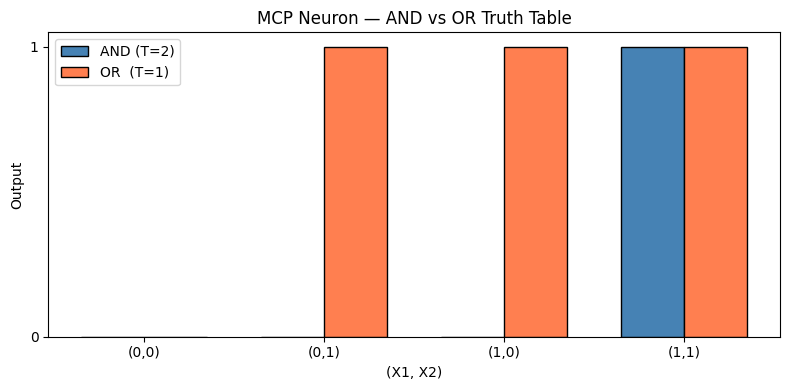

In [6]:
inputs = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
x = np.arange(len(inputs))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width/2, result_and, width, label='AND (T=2)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, result_or,  width, label='OR  (T=1)', color='coral',     edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(inputs)
ax.set_yticks([0, 1])
ax.set_xlabel('(X1, X2)')
ax.set_ylabel('Output')
ax.set_title('MCP Neuron — AND vs OR Truth Table')
ax.legend()
plt.tight_layout()
plt.show()

---
### 3.2.1 Question 1 — Limitations of MCP Neurons

1. **No learning** — Weights and thresholds are hand-crafted by the designer, not learned from data. Every new problem requires manual re-engineering.
2. **Binary inputs only** — MCP neurons only accept inputs of 0 or 1. They cannot process continuous or real-valued signals.
3. **No learnable weights** — All excitatory inputs are treated equally (weight = 1). There is no mechanism to represent that some inputs matter more than others.
4. **Fixed threshold** — The threshold `T` must be chosen manually and cannot adapt to the data.
5. **Cannot solve non-linearly separable problems** — XOR, for example, cannot be represented by a single MCP neuron regardless of the threshold chosen.
6. **No bias term** — Without a bias, the decision boundary is forced to pass through the origin.
7. **Inhibitory inputs are all-or-nothing** — Any single inhibitory input silences the neuron completely, which is overly restrictive.

---

### 3.2.1 Question 2 — Can MCP Solve XOR?

**XOR truth table:**

| X1 | X2 | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

**Answer: No, a single MCP neuron cannot implement XOR.**

XOR is not linearly separable — no single straight line (i.e., no single threshold on the sum) can separate the output-1 cases `(0,1)` and `(1,0)` from the output-0 cases `(0,0)` and `(1,1)`.

With a simple sum rule: if we try `T=1` → output for `(1,1)` would be 1 (wrong). If we try `T=2` → outputs for `(0,1)` and `(1,0)` would be 0 (wrong). No threshold works.

**A workaround using two MCP neurons in combination:**  
XOR = (X1 OR X2) AND NOT (X1 AND X2)  
This requires at least two neurons arranged in a small network — demonstrating the need for multi-layer models, which the MCP neuron alone cannot provide.

In [7]:
# ── Demonstrating that no single threshold works for XOR ─────────────────────
print('XOR cannot be solved by a single MCP neuron:')
print('Sum for (0,0)=0, (0,1)=1, (1,0)=1, (1,1)=2')
print()
for T in range(3):
    out = [1 if (x1+x2) >= T else 0 for x1, x2 in [(0,0),(0,1),(1,0),(1,1)]]
    xor = [0, 1, 1, 0]
    match = '✓ MATCHES XOR' if out == xor else '✗ does not match'
    print(f'  T={T}: output={out}  {match}')

print()
print('Conclusion: No threshold T produces XOR output → XOR is not linearly separable.')
print('Solution: Stack two neurons: XOR = OR(X1,X2) AND NOT AND(X1,X2)')

XOR cannot be solved by a single MCP neuron:
Sum for (0,0)=0, (0,1)=1, (1,0)=1, (1,1)=2

  T=0: output=[1, 1, 1, 1]  ✗ does not match
  T=1: output=[0, 1, 1, 1]  ✗ does not match
  T=2: output=[0, 0, 0, 1]  ✗ does not match

Conclusion: No threshold T produces XOR output → XOR is not linearly separable.
Solution: Stack two neurons: XOR = OR(X1,X2) AND NOT AND(X1,X2)


---
## 4. The Perceptron

The **Perceptron** (Rosenblatt, 1958) extends MCP by introducing:
- **Learnable numerical weights** (one per input feature)
- **A learnable bias** term
- **An adaptive learning rule** that updates weights based on prediction errors

### 4.3 Task 2 — Perceptron for 0 vs 1 Classification

#### Dataset Configuration

In [8]:

USE_CSV        = True
CSV_PATH_01    = '/content/drive/MyDrive/AIML/Week3/mnist_0_and_1.csv'
CSV_PATH_35    = '/content/drive/MyDrive/AIML/Week3/mnist_3_and_5.csv'

#### Step 1 — Load Dataset (0 vs 1)

In [9]:
def load_digit_pair(digit_a, digit_b, csv_path=None, use_csv=False):
    """
    Load a binary-class subset of MNIST for two digits.
    Labels are remapped: digit_a → 0, digit_b → 1.

    Args:
        digit_a, digit_b (int): The two digit classes to keep.
        csv_path (str)        : Path to CSV (used when use_csv=True).
        use_csv  (bool)       : If True reads CSV; else fetches via sklearn.
    Returns:
        X (ndarray): Normalised pixel features, shape (n, 784).
        y (ndarray): Binary labels 0 or 1, shape (n,).
    """
    if use_csv:
        print(f'Loading from CSV: {csv_path}')
        df = pd.read_csv(csv_path)
        # Support both 'label' column name conventions
        label_col = 'label' if 'label' in df.columns else df.columns[0]
        y_raw = df[label_col].values
        X_raw = df.drop(columns=[label_col]).values.astype(np.float64)
        # Filter to the two requested digits
        mask = np.isin(y_raw, [digit_a, digit_b])
        X_raw, y_raw = X_raw[mask], y_raw[mask]
    else:
        print(f'Fetching MNIST via sklearn (first run ~30 s)...')
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
        y_all = mnist.target.astype(int)
        X_all = mnist.data.astype(np.float64)
        mask  = np.isin(y_all, [digit_a, digit_b])
        X_raw, y_raw = X_all[mask], y_all[mask]

    # Normalise pixels to [0, 1]
    X = X_raw / 255.0

    # Remap: digit_a → 0, digit_b → 1
    y = np.where(y_raw == digit_a, 0, 1)

    print(f'Loaded {len(y)} samples  |  class {digit_a}: {np.sum(y==0)}  |  class {digit_b}: {np.sum(y==1)}')
    print(f'Feature matrix shape: {X.shape}  |  Label vector shape: {y.shape}')
    return X, y


# ── Load 0 vs 1 ───────────────────────────────────────────────────────────────
X_01, y_01 = load_digit_pair(0, 1, csv_path=CSV_PATH_01, use_csv=USE_CSV)

Loading from CSV: /content/drive/MyDrive/AIML/Week3/mnist_0_and_1.csv
Loaded 12665 samples  |  class 0: 5923  |  class 1: 6742
Feature matrix shape: (12665, 784)  |  Label vector shape: (12665,)


#### Questions 1 & 2 — Shape of X

**Question 1: What does the shape of X represent?**  
The shape `(n, 784)` means there are `n` samples and 784 features per sample. Each MNIST image is 28×28 pixels = 784 pixels, flattened into a single row vector. So each row of X is one digit image.

**Question 2: What does the shape of y represent?**  
The shape `(n,)` means there are `n` labels, one integer per sample. Here labels are either `0` (digit zero) or `1` (digit one), forming the binary classification target.

#### Step 2 — Visualise the Dataset

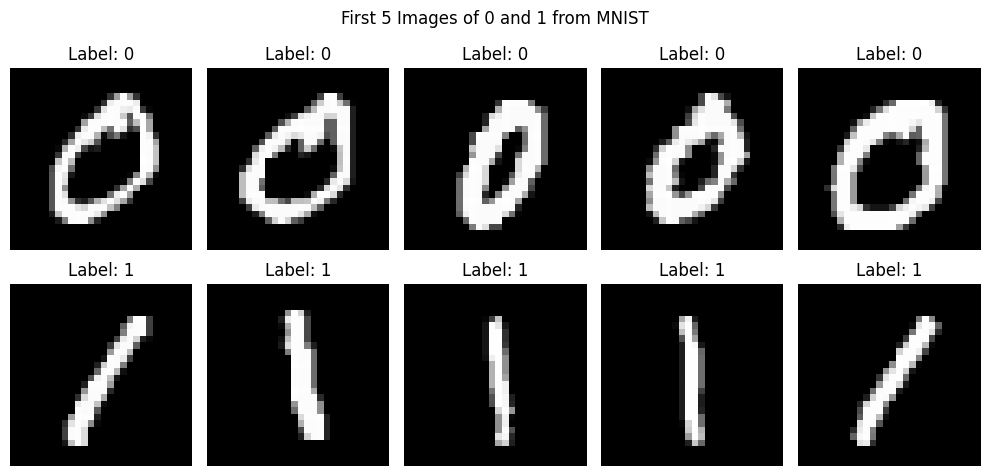

In [10]:
def visualise_digit_pair(X, y, digit_a, digit_b, n_show=5):
    """
    Plot n_show example images for each of two digit classes side by side.
    """
    images_0 = X[y == 0]   # digit_a
    images_1 = X[y == 1]   # digit_b

    if len(images_0) < n_show or len(images_1) < n_show:
        print(f'Error: Not enough images to show {n_show} per class.')
        return

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2, 5))
    for i in range(n_show):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(f'Label: {digit_a}')
        axes[0, i].axis('off')

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(f'Label: {digit_b}')
        axes[1, i].axis('off')

    plt.suptitle(f'First {n_show} Images of {digit_a} and {digit_b} from MNIST')
    plt.tight_layout()
    plt.show()


visualise_digit_pair(X_01, y_01, digit_a=0, digit_b=1)

#### Step 3 — Initialise Weights and Bias

In [11]:
# Initialise weights and bias
weights_01    = np.zeros(X_01.shape[1])   # 784 weights, one per pixel
bias_01       = 0
learning_rate = 0.1
epochs        = 100

print(f'Weights shape : {weights_01.shape}   (one weight per pixel feature)')
print(f'Bias          : {bias_01}')
print(f'Learning rate : {learning_rate}')
print(f'Epochs        : {epochs}')

Weights shape : (784,)   (one weight per pixel feature)
Bias          : 0
Learning rate : 0.1
Epochs        : 100


#### Questions 3 & 4 — Weights Initialisation

**Question 3: What does the weights array represent in this context?**  
The weights array has 784 values, one for each pixel in the 28×28 image. Each weight represents the **importance** of the corresponding pixel in distinguishing between digit 0 and digit 1. Pixels in regions that differ significantly between the two digits will receive larger weights after training, while uninformative pixels (e.g., corners that are always black) will retain near-zero weights.

**Question 4: Why initialise weights to zero? What effect could this have?**  
Initialising to zero is common for the perceptron because:
- It provides a neutral, unbiased starting point.
- The perceptron learning rule is guaranteed to converge for linearly separable data regardless of initialisation.

However, zero initialisation can be problematic for deeper networks (the *symmetry breaking* problem — all neurons learn the same thing). For the single perceptron here it is safe because the weight update rule `Δw = η(y − ŷ)x` breaks symmetry as soon as the first misclassification occurs and different features receive different updates.

#### Step 4 — Decision (Activation) Function

In [12]:
def decision_function(X, weights, bias):
    """
    Apply the step activation function to compute predicted labels.

    Steps:
        1. Compute weighted sum:  z = X · weights + bias
        2. Apply step function:   ŷ = 1 if z >= 0, else 0

    Parameters:
        X       (ndarray): Feature matrix  (n_samples, n_features)
        weights (ndarray): Weight vector   (n_features,)
        bias    (float)  : Bias scalar
    Returns:
        y_pred_all (ndarray): Predicted binary labels  (n_samples,)
    """
    # Aggregation: linear combination of inputs and weights
    predictions = np.dot(X, weights) + bias

    # Step (threshold) activation function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


# ── Quick sanity check with zero weights ──────────────────────────────────────
y_init = decision_function(X_01[:5], weights_01, bias_01)
print('Predictions with zero-initialised weights (all should be 1):', y_init)
# With all-zero weights → z = 0 → step function → 1 for every sample

Predictions with zero-initialised weights (all should be 1): [1 1 1 1 1]


#### Step 5 — Perceptron Learning Algorithm

In [13]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    For each epoch:
        For each sample (xi, yi):
            1. Compute weighted sum:  z = xi · weights + bias
            2. Apply step function:   ŷ = 1 if z >= 0 else 0
            3. If ŷ ≠ y:
                   Δw = η * (y - ŷ) * xi
                   Δb = η * (y - ŷ)
                   weights += Δw
                   bias    += Δb

    Parameters:
        X             (ndarray): Feature matrix      (n_samples, n_features)
        y             (ndarray): True binary labels  (n_samples,)
        weights       (ndarray): Initial weights     (n_features,)
        bias          (float)  : Initial bias
        learning_rate (float)  : Step size η  (default 0.1)
        epochs        (int)    : Max training iterations (default 100)
    Returns:
        weights  (ndarray): Learned weights
        bias     (float)  : Learned bias
        accuracy (float)  : Final training accuracy (fraction correct)
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True   # assume convergence; flip if any update occurs

        for i in range(n_samples):
            # Step 1: Weighted sum (aggregation)
            output = np.dot(X[i], weights) + bias

            # Step 2: Step activation → predicted label
            y_pred = 1 if output >= 0 else 0

            # Step 3: Update weights if prediction is wrong
            if y_pred != y[i]:
                error = y[i] - y_pred                   # +1 or -1
                weights = weights + learning_rate * error * X[i]
                bias    = bias    + learning_rate * error
                convergence_flag = False

        # Early stopping if no updates occurred in this epoch
        if convergence_flag:
            print(f'Converged at epoch {epoch + 1}')
            break

        if (epoch + 1) % 10 == 0:
            # Compute running accuracy
            y_hat = decision_function(X, weights, bias)
            acc   = np.mean(y_hat == y)
            print(f'Epoch {epoch+1:>3d}/{epochs}  |  Training Accuracy: {acc:.4f}')

    # Final accuracy
    y_final  = decision_function(X, weights, bias)
    accuracy = np.mean(y_final == y)

    return weights, bias, accuracy

#### Questions 5, 6, 7 — Understanding the Algorithm

**Question 5: What is the purpose of `output = np.dot(X[i], weights) + bias`?**  
This computes the **weighted sum** (net input) for sample `i`. It is the dot product of the feature vector with the weight vector, plus the bias. This scalar value `z` represents how strongly the current weights "vote" for one class over the other. It is the pre-activation value passed to the step function.

**Question 6: What happens when the prediction is wrong? How are weights updated?**  
When `y_pred ≠ y[i]`, the error `= y[i] - y_pred` is either `+1` (predicted 0, true 1) or `-1` (predicted 1, true 0).  
- Weight update: `Δw = η × error × x`  — each weight is nudged in the direction that would have produced the correct output.  
- Bias update:  `Δb = η × error`  — the bias shifts the decision boundary toward the correct side.  
Over many samples, these corrections gradually move the decision boundary to separate the two classes.

**Question 7: Why is final accuracy important, and what do you expect?**  
The final training accuracy tells us how well the perceptron has learned to separate the two classes on the data it was trained on. For 0 vs 1, these digits are visually very different and are **linearly separable** — the perceptron convergence theorem guarantees 100% training accuracy. We therefore expect accuracy very close to (or exactly) 1.0 after sufficient epochs.

#### Step 6 — Train the Perceptron (0 vs 1)

In [14]:
print('Training Perceptron on 0 vs 1 ...')
print('─' * 50)

weights_01, bias_01, accuracy_01 = train_perceptron(
    X_01, y_01,
    weights       = np.zeros(X_01.shape[1]),
    bias          = 0,
    learning_rate = 0.1,
    epochs        = 100
)

print('─' * 50)
print(f'Final Training Accuracy (0 vs 1): {accuracy_01:.4f}')

Training Perceptron on 0 vs 1 ...
──────────────────────────────────────────────────
Converged at epoch 7
──────────────────────────────────────────────────
Final Training Accuracy (0 vs 1): 1.0000


#### Step 7 — Visualise Misclassified Images (0 vs 1)

In [15]:
def visualise_misclassified(X, y, weights, bias, digit_a, digit_b, n_show=10):
    """
    Identify and display misclassified images.
    """
    predictions = np.dot(X, weights) + bias
    y_pred      = np.where(predictions >= 0, 1, 0)

    final_accuracy = np.mean(y_pred == y)
    print(f'Final Accuracy: {final_accuracy:.4f}')

    misclassified_idx = np.where(y_pred != y)[0]
    print(f'Misclassified samples: {len(misclassified_idx)} / {len(y)}')

    if len(misclassified_idx) == 0:
        print('All images were correctly classified! ✓')
        return

    # Show up to n_show misclassified images
    show_idx = misclassified_idx[:n_show]
    ncols = min(5, len(show_idx))
    nrows = int(np.ceil(len(show_idx) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.5))
    for ax, idx in zip(np.array(axes).flat, show_idx):
        true_digit = digit_a if y[idx] == 0 else digit_b
        pred_digit = digit_a if y_pred[idx] == 0 else digit_b
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'Pred:{pred_digit}  True:{true_digit}', fontsize=8, color='red')
        ax.axis('off')

    plt.suptitle(f'Misclassified Images ({digit_a} vs {digit_b})', fontsize=12)
    plt.tight_layout()
    plt.show()


visualise_misclassified(X_01, y_01, weights_01, bias_01, digit_a=0, digit_b=1)

Final Accuracy: 1.0000
Misclassified samples: 0 / 12665
All images were correctly classified! ✓


#### Questions 8 & 9 — Misclassified Images

**Question 8: What does `misclassified_idx` store, and how is it used?**  
`misclassified_idx` is an array of integer indices (row numbers in X) where the predicted label does not match the true label — i.e., `y_pred[i] ≠ y[i]`. It is used to index into `X` and `y` to retrieve just the wrongly-predicted images and their labels, so we can visualise them and understand what kinds of samples confuse the model.

**Question 9: How do you interpret "All images were correctly classified!"?**  
This means the perceptron found a hyperplane (decision boundary) that perfectly separates digit 0 from digit 1 in the 784-dimensional feature space. It confirms that 0 vs 1 is **linearly separable** — consistent with the Perceptron Convergence Theorem, which guarantees that the algorithm will find such a boundary in finite steps when one exists. It does **not** necessarily mean the model will generalise well to unseen data (that would require evaluating on a held-out test set).

#### Bonus — Visualise Learned Weights

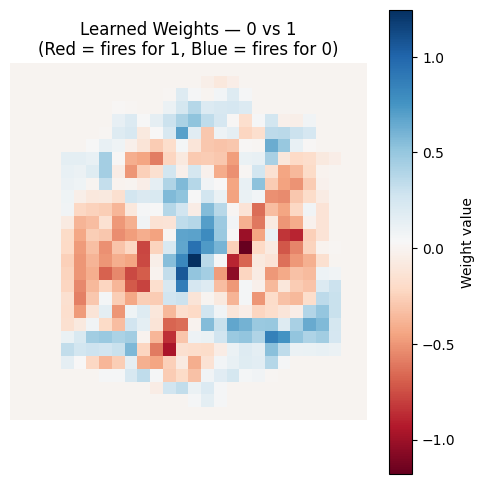

In [16]:
# Reshape the weight vector back to a 28×28 image to see which pixels matter
plt.figure(figsize=(5, 5))
plt.imshow(weights_01.reshape(28, 28), cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Weight value')
plt.title('Learned Weights — 0 vs 1\n(Red = fires for 1, Blue = fires for 0)')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 4.4 Task 3 — Perceptron for 3 vs 5 Classification

Digits 3 and 5 are visually similar (both have curves and similar stroke patterns), making this a harder classification task. We repeat the same pipeline.

#### Step 1 — Load Dataset (3 vs 5)

In [17]:
X_35, y_35 = load_digit_pair(3, 5, csv_path=CSV_PATH_35, use_csv=USE_CSV)

Loading from CSV: /content/drive/MyDrive/AIML/Week3/mnist_3_and_5.csv
Loaded 2741 samples  |  class 3: 1484  |  class 5: 1257
Feature matrix shape: (2741, 784)  |  Label vector shape: (2741,)


#### Step 2 — Visualise the Dataset (3 vs 5)

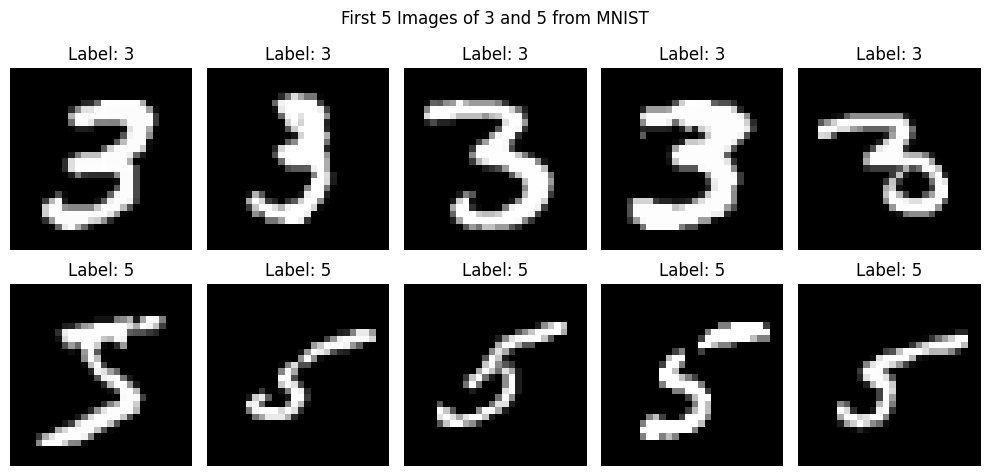

In [18]:
visualise_digit_pair(X_35, y_35, digit_a=3, digit_b=5)

#### Step 3 — Initialise Weights and Bias (3 vs 5)

In [19]:
weights_35    = np.zeros(X_35.shape[1])
bias_35       = 0
learning_rate = 0.1
epochs        = 100

print(f'Weights shape : {weights_35.shape}')
print(f'Bias          : {bias_35}')

Weights shape : (784,)
Bias          : 0


#### Step 4 — Decision Function + Step 5 — Train Perceptron (3 vs 5)

In [20]:
print('Training Perceptron on 3 vs 5 ...')
print('─' * 50)

weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35,
    weights       = np.zeros(X_35.shape[1]),
    bias          = 0,
    learning_rate = 0.1,
    epochs        = 100
)

print('─' * 50)
print(f'Final Training Accuracy (3 vs 5): {accuracy_35:.4f}')

Training Perceptron on 3 vs 5 ...
──────────────────────────────────────────────────
Epoch  10/100  |  Training Accuracy: 0.9632
Epoch  20/100  |  Training Accuracy: 0.9489
Epoch  30/100  |  Training Accuracy: 0.9712
Epoch  40/100  |  Training Accuracy: 0.9704
Epoch  50/100  |  Training Accuracy: 0.9537
Epoch  60/100  |  Training Accuracy: 0.9767
Epoch  70/100  |  Training Accuracy: 0.9650
Epoch  80/100  |  Training Accuracy: 0.9861
Epoch  90/100  |  Training Accuracy: 0.9792
Epoch 100/100  |  Training Accuracy: 0.9916
──────────────────────────────────────────────────
Final Training Accuracy (3 vs 5): 0.9916


#### Step 6 — Visualise Misclassified Images (3 vs 5)

Final Accuracy: 0.9916
Misclassified samples: 23 / 2741


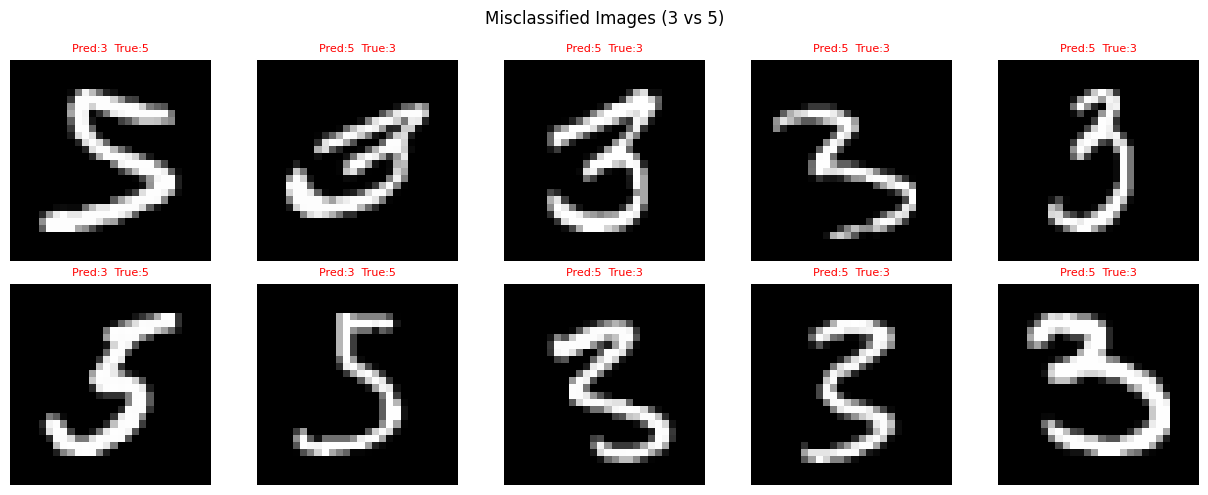

In [21]:
visualise_misclassified(X_35, y_35, weights_35, bias_35, digit_a=3, digit_b=5)

#### Bonus — Visualise Learned Weights (3 vs 5)

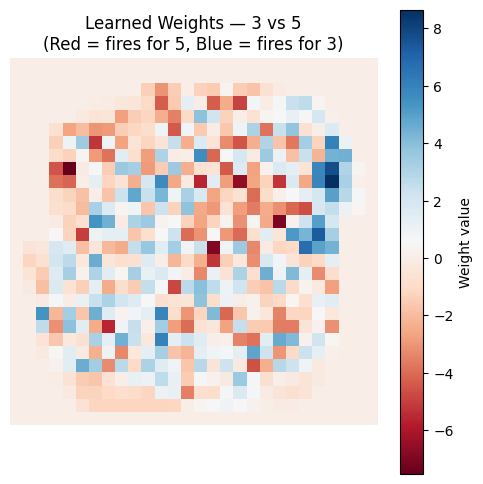

In [22]:
plt.figure(figsize=(5, 5))
plt.imshow(weights_35.reshape(28, 28), cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Weight value')
plt.title('Learned Weights — 3 vs 5\n(Red = fires for 5, Blue = fires for 3)')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Comparison — 0 vs 1 vs 3 vs 5

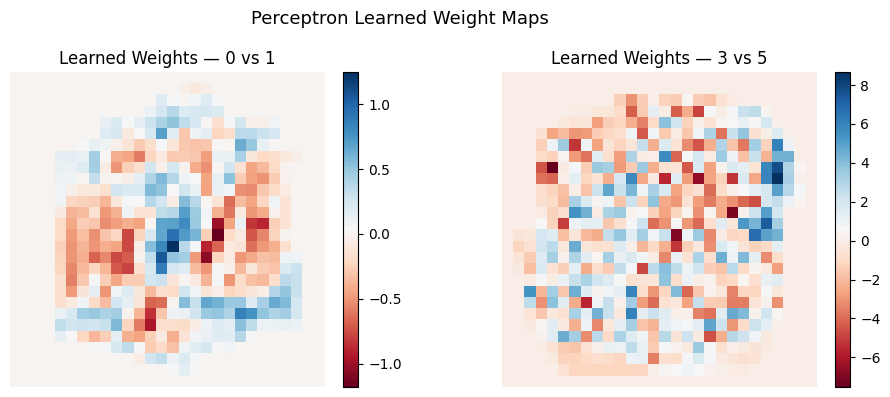


Accuracy Summary
  0 vs 1:  1.0000
  3 vs 5:  0.9916


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, weights, title in [
    (axes[0], weights_01, 'Learned Weights — 0 vs 1'),
    (axes[1], weights_35, 'Learned Weights — 3 vs 5')
]:
    im = ax.imshow(weights.reshape(28, 28), cmap='RdBu', interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Perceptron Learned Weight Maps', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nAccuracy Summary')
print(f'  0 vs 1:  {accuracy_01:.4f}')
print(f'  3 vs 5:  {accuracy_35:.4f}')

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 4.5 Conclusion — 3 vs 5 Classification

**Observations from the misclassified images:**
The misclassified samples (as shown in the visualisation above) are images where digits 3 and 5 look ambiguous — e.g., a loosely written 3 whose upper curve resembles the top arc of a 5, or a 5 whose lower curve is drawn similarly to a 3. These edge cases lie near the decision boundary and reveal the fundamental limitation of a linear classifier.

**Why 3 vs 5 is harder than 0 vs 1:**
- Digits 0 and 1 are structurally very different (closed oval vs vertical stroke), so they are well linearly separable.
- Digits 3 and 5 share similar curves and stroke patterns, making them much harder to separate with a single linear decision boundary.

**The key limitation of the Perceptron:**
The Perceptron can **only learn a linear decision boundary** — a hyperplane in the feature space. If two classes are not linearly separable, the algorithm will never converge and will keep oscillating. Even for 3 vs 5 (which are roughly linearly separable), accuracy may not reach 100% because:
1. Some handwritten examples are genuinely ambiguous.
2. The perceptron has no mechanism to model curved or complex decision boundaries.

**Solution — Multi-Layer Networks:**  
The limitations of the single perceptron (and MCP neuron before it) motivated the development of **multi-layer perceptrons (MLPs)** and eventually **deep neural networks**, which can learn non-linear decision boundaries by stacking multiple layers of neurons with non-linear activation functions.